最新数据日期：2025-09-19
             open   high    low  close      volume
2025-09-15  22.81  23.95  22.79  23.49  11526623.0
2025-09-16  23.50  23.58  23.00  23.12   7718786.0
2025-09-17  23.18  23.18  22.85  23.01   4435250.0
2025-09-18  23.00  23.03  22.32  22.52   6725937.0
2025-09-19  22.50  23.28  22.41  23.15   7512761.0


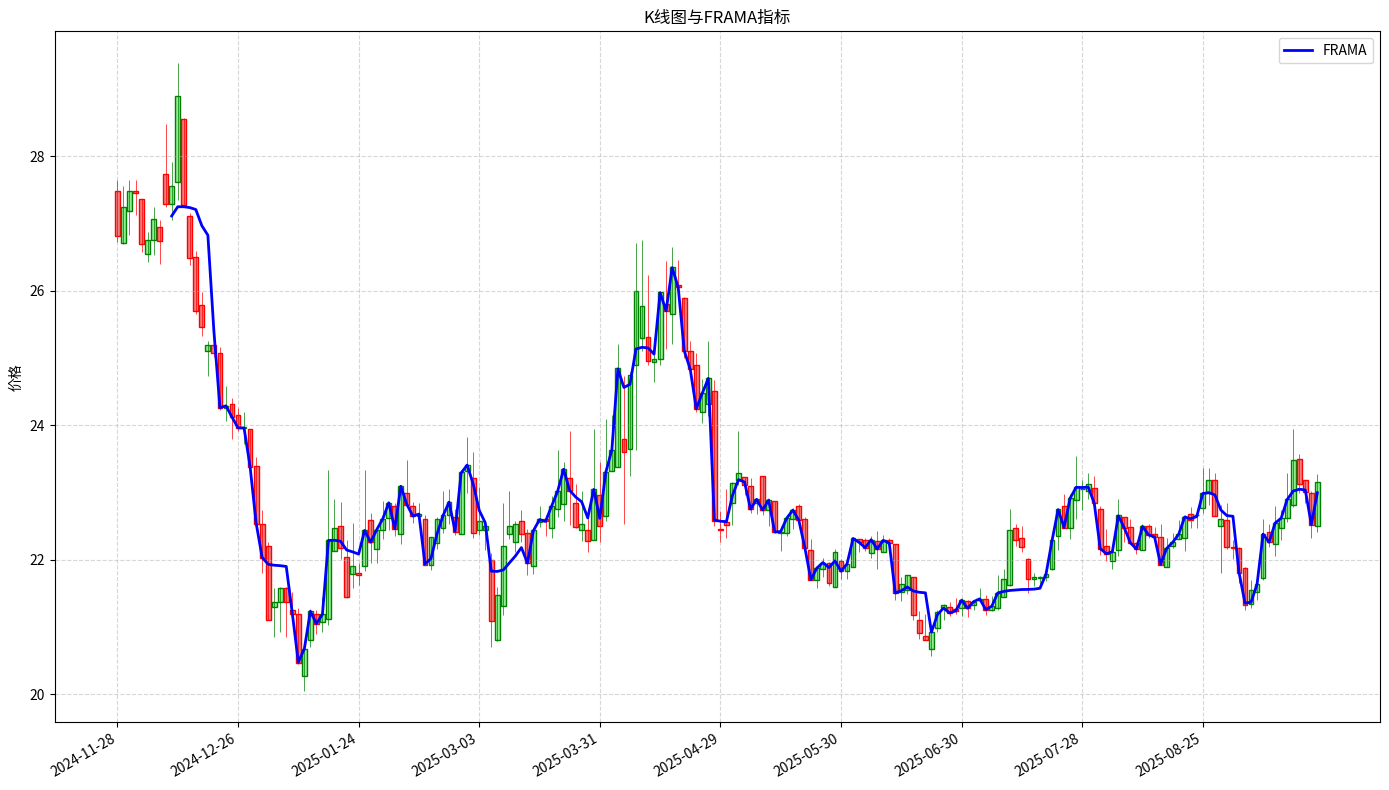

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import mplfinance as mpf
import argparse
from matplotlib.dates import DateFormatter
from matplotlib.patches import Rectangle
from matplotlib import gridspec
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
from datetime import datetime
def calculate_frama(close, high, low, period=16, FC=1, SC=200):
    """
    计算FRAMA（分形自适应移动平均）
    
    参数:
    close: 收盘价序列
    high: 最高价序列
    low: 最低价序列
    period: 计算窗口周期，默认16
    FC: 快速平滑常数，默认1
    SC: 慢速平滑常数，默认200
    
    返回:
    FRAMA值序列
    """
    n = len(close)
    frama = np.zeros(n)
    frama[:period-1] = np.nan
    
    # 使用指数移动平均初始化
    frama[period-1] = np.mean(close[:period])
    
    for i in range(period, n):
        # 计算分形维度
        # 当前窗口的最高最低价范围
        H1 = np.max(high[i-period:i])
        L1 = np.min(low[i-period:i])
        N1 = (H1 - L1) / period if period > 0 else 0
        
        # 前半段
        H2 = np.max(high[i-period//2:i])
        L2 = np.min(low[i-period//2:i])
        N2 = (H2 - L2) / (period//2) if period//2 > 0 else 0
        
        # 后半段
        H3 = np.max(high[i-period:i-period//2])
        L3 = np.min(low[i-period:i-period//2])
        N3 = (H3 - L3) / (period//2) if period//2 > 0 else 0
        
        # 分形维度计算
        if N1 > 0 and N2 > 0 and N3 > 0:
            D = (np.log(N1 + N2) - np.log(N3)) / np.log(2)
        else:
            D = 1
        
        # 限制D在1-2之间
        D = max(1, min(2, D))
        
        # 计算alpha
        alpha = np.exp(-4.6 * (D - 1))
        
        # 限制alpha在SC和FC之间
        alpha = max(2/(SC+1), min(2/(FC+1)-0.01, alpha))
        
        # 计算FRAMA
        frama[i] = alpha * close.iloc[i] + (1 - alpha) * frama[i-1]
    
    return frama


def plot_candlestick_with_frama(df, frama_period=16):
    """
    绘制K线图并添加FRAMA指标
    
    参数:
    df: 包含OHLC数据的DataFrame (列名应为小写: open, high, low, close)
    frama_period: FRAMA计算周期
    """
    # 计算FRAMA
    df['FRAMA'] = calculate_frama(df['close'], df['high'], df['low'], period=frama_period)
    
    # 创建图表和子图
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # 设置日期格式
    date_format = mdates.DateFormatter('%Y-%m-%d')
    ax.xaxis.set_major_formatter(date_format)
    fig.autofmt_xdate()
    
    # 计算K线的宽度（基于数据点数量）
    width = 0.8
    width2 = 0.1
    
    # 提取OHLC数据
    dates = df.index
    opens = df['open']
    highs = df['high']
    lows = df['low']
    closes = df['close']
    
    # 绘制K线
    for i in range(len(df)):
        # 确定颜色（绿色表示上涨，红色表示下跌）
        if closes.iloc[i] >= opens.iloc[i]:
            color = 'green'
            body_color = 'lightgreen'  # 使用浅色填充
            lower = opens.iloc[i]
            height = closes.iloc[i] - opens.iloc[i]
        else:
            color = 'red'
            body_color = 'lightcoral'  # 使用浅色填充
            lower = closes.iloc[i]
            height = opens.iloc[i] - closes.iloc[i]
        
        # 确保高度不为零（避免绘制问题）
        if height == 0:
            height = 0.01
        
        # 绘制实体
        rect = Rectangle((i - width/2, lower), width, height, 
                         facecolor=body_color, edgecolor=color)
        ax.add_patch(rect)
        
        # 绘制上下影线
        ax.vlines(i, lows.iloc[i], highs.iloc[i], color=color, linewidth=0.5)
    
    # 绘制FRAMA - 只绘制非NaN的部分
    frama_values = df['FRAMA'].values
    valid_indices = ~np.isnan(frama_values)
    
    if np.any(valid_indices):
        ax.plot(np.arange(len(df))[valid_indices], 
                frama_values[valid_indices], 
                label='FRAMA', color='blue', linewidth=2)
    
    # 设置标题和标签
    ax.set_title('K线图与FRAMA指标')
    ax.set_ylabel('价格')
    ax.legend()
    
    # 设置x轴刻度
    ax.set_xticks(range(0, len(df), max(1, len(df)//10)))
    ax.set_xticklabels([dates[i].strftime('%Y-%m-%d') for i in range(0, len(df), max(1, len(df)//10))])
    
    # 添加网格
    ax.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    








# ================= 主程序 =================
if __name__ == "__main__":
    # MindGo数据获取（需在平台环境中运行）
    # 方法一：使用平台内置数据接口
    from mindgo_api import *
    # 创建命令行参数解析器
    parser = argparse.ArgumentParser(description='Get stock data by code.')
    parser.add_argument(
        '--code',                # 参数名
        type=str,
        default='002791.SZ',     # 默认证券代码
        help='Stock code (default: 300032.SZ)'
    )
    
    # 解析参数时忽略未知参数
    args, unknown = parser.parse_known_args()  # 关键修改
    df = get_price(
        securities=args.code,  # 注意参数名是复数但支持单个代码
        #end_date=datetime.date.today().strftime('%Y%m%d'),  # 结束日期设为今天
        end_date='20250920',  # 结束日期设为今天
        fre_step='1d',           # 日线频率
        fields=['open','high','low','close','volume'],
        fq='pre',                # 前复权
        bar_count=200,           # 获取250根K线
        skip_paused=True         # 跳过停牌日
    ).sort_index()  # 清除证券代码索引层级
   
    # 检查数据样例
    print(f"最新数据日期：{df.index[-1].strftime('%Y-%m-%d')}")
    print(df.tail())
    
       # 绘制K线图并添加FRAMA
    plot_candlestick_with_frama(df, frama_period=10)
